## Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import BertForQuestionAnswering, Trainer, TrainingArguments, pipeline

## Load + Tokenize

In [2]:
dataset = load_dataset("imdb")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(x):
    return tokenizer(x["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

## Model + Trainer

In [3]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].select(range(2000)),
    eval_dataset=dataset["test"].select(range(500)),
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Train

In [4]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.049788
100,0.000243
150,0.000147
200,0.000113
250,0.000100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.010078264035284518, metrics={'train_runtime': 1469.0719, 'train_samples_per_second': 1.361, 'train_steps_per_second': 0.17, 'total_flos': 131555527680000.0, 'train_loss': 0.010078264035284518, 'epoch': 1.0})

## Loss Graph

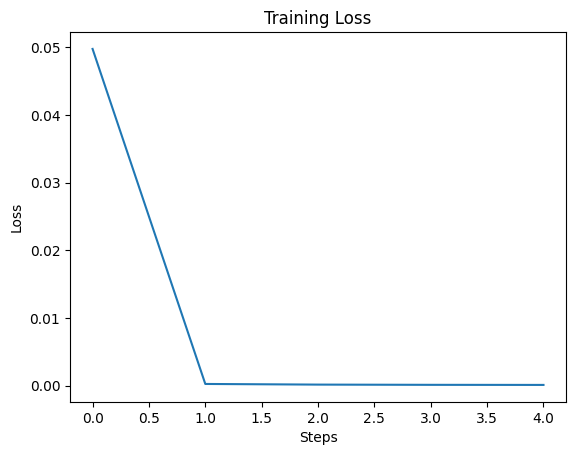

In [5]:
logs = trainer.state.log_history
losses = [x["loss"] for x in logs if "loss" in x]

plt.plot(losses)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## Prediction

In [6]:
samples = ["Great movie", "Worst film ever", "Not bad"]

for s in samples:
    inputs = tokenizer(s, return_tensors="pt")
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    print(s, "->", "Positive" if pred==1 else "Negative")

Great movie -> Negative
Worst film ever -> Negative
Not bad -> Negative


## Load Dataset

In [7]:
dataset_qa = load_dataset("squad")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

## Preprocess

In [8]:
def preprocess(x):
    inputs = tokenizer(
        x["question"],
        x["context"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    start_positions = []
    end_positions = []

    for ans in x["answers"]:
        if len(ans["answer_start"]) > 0:
            start = ans["answer_start"][0]
            end = start + len(ans["text"][0])
        else:
            start, end = 0, 0

        start_positions.append(start)
        end_positions.append(end)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs

dataset_qa = dataset_qa.map(preprocess, batched=True)

dataset_qa.set_format(type="torch", columns=[
    "input_ids", "attention_mask", "start_positions", "end_positions"
])

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

## QA Model + Trainer

In [9]:
model_qa = BertForQuestionAnswering.from_pretrained("bert-base-uncased")

training_args_qa = TrainingArguments(
    output_dir="./qa_results",
    per_device_train_batch_size=4,
    num_train_epochs=1,
    report_to="none"
)

trainer_qa = Trainer(
    model=model_qa,
    args=training_args_qa,
    train_dataset=dataset_qa["train"].select(range(2000)),
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

## Train QA

In [10]:
trainer_qa.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,5.539942


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=5.53994189453125, metrics={'train_runtime': 2976.4591, 'train_samples_per_second': 0.672, 'train_steps_per_second': 0.168, 'total_flos': 261296756736000.0, 'train_loss': 5.53994189453125, 'epoch': 1.0})

## Create Pipeline

In [11]:
qa_pipeline = pipeline("question-answering", model=model_qa, tokenizer=tokenizer)

## QA Inference

In [12]:
res = qa_pipeline(
    question="Who developed BERT?",
    context="BERT was developed by Google researchers."
)

print("Q:", "Who developed BERT?")
print("A:", res["answer"])

Q: Who developed BERT?
A: BERT was developed by Google researchers
